# Task 3: 6-Month Forecasting of TSLA Stock Prices

**Objective:**  
- Use the best-performing model from Task 2 (LSTM) to forecast future TSLA stock prices for 6 months.  
- Reconstruct prices from predicted returns.  
- Visualize forecasted prices and returns.  
- Analyze trends, potential market opportunities, and risks.


In [4]:
# Cell 1: Set up paths and imports
import sys
from pathlib import Path

# Add the project root to sys.path
project_root = Path.cwd().parent  # adjust if notebook is deeper
sys.path.append(str(project_root))

# Now imports from src will work
from src.forecast_lstm import load_forecasted_tsla, load_expected_returns
from src.price_reconstruction import reconstruct_prices_from_returns
import pandas as pd


FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/TSLA_cleaned.csv'

In [5]:
# Load cleaned TSLA price data
tsla_df = pd.read_csv("../data/processed/TSLA_cleaned.csv", parse_dates=["Date"])
tsla_df.set_index("Date", inplace=True)

# Quick view
tsla_df.head()


,Close,High,Low,Open,Volume,Return,RollingVol
Date,,,,,,,
2015-02-02,14.062667,14.130000,13.553333,13.598000,62238000,0.036051,0.024221
2015-02-03,14.557333,14.691333,14.084667,14.214667,72393000,0.035176,0.023592
2015-02-04,14.570000,14.765333,14.453333,14.552667,49581000,0.000870,0.023579
2015-02-05,14.732667,15.032000,14.642667,14.658667,52843500,0.011165,0.023651
2015-02-06,14.490667,14.893333,14.433333,14.800000,48658500,-0.016426,0.024019


In [6]:
lstm_model = load_model("../models/lstm_tsla_model.keras")
lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,355 (122.48 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,904 (81.66 KB)

In [7]:
# Forecast horizon
forecast_horizon = 126  # ~6 months of trading days

# Create sequences from last known returns
last_returns = tsla_df["Return"].values
forecast_sequences = create_forecast_sequence(last_returns, sequence_length=60, n_forecast=forecast_horizon)


NameError: name 'create_forecast_sequence' is not defined

In [ ]:
# Generate predicted returns
forecasted_returns = lstm_model.predict(forecast_sequences)

# Check results
forecasted_returns[:5]


In [ ]:
# Reconstruct price series from last known close price
last_close_price = tsla_df["Close"].iloc[-1]
forecasted_prices = reconstruct_prices(last_close_price, forecasted_returns.flatten())

# Create forecast DataFrame
forecast_dates = pd.date_range(start=tsla_df.index[-1] + pd.Timedelta(days=1), periods=forecast_horizon)
forecast_df = pd.DataFrame({
    "Forecasted_Return": forecasted_returns.flatten(),
    "Forecasted_Close": forecasted_prices
}, index=forecast_dates)

# Save results
forecast_df.to_csv("../data/processed/TSLA_forecasted_6mo.csv")
forecast_df.head()


In [ ]:
plt.figure(figsize=(12,6))
plt.plot(tsla_df["Close"][-90:], label="Last 90 Days Historical")
plt.plot(forecast_df["Forecasted_Close"], label="6-Month Forecast")
plt.title("TSLA Stock Price Forecast")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()


In [ ]:
plt.figure(figsize=(12,4))
plt.plot(forecast_df["Forecasted_Return"], label="Forecasted Returns")
plt.title("TSLA Forecasted Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.axhline(0, color="black", linestyle="--")
plt.legend()
plt.show()


Historical TSLA Prices:


,Date,Close,High,Low,Open,Volume,Return,RollingVol
0,2015-02-02,14.062667,14.130000,13.553333,13.598000,62238000,0.036051,0.024221
1,2015-02-03,14.557333,14.691333,14.084667,14.214667,72393000,0.035176,0.023592
2,2015-02-04,14.570000,14.765333,14.453333,14.552667,49581000,0.000870,0.023579
3,2015-02-05,14.732667,15.032000,14.642667,14.658667,52843500,0.011165,0.023651
4,2015-02-06,14.490667,14.893333,14.433333,14.800000,48658500,-0.016426,0.024019


Forecasted TSLA Prices and Returns:


,Date,Forecasted_Return,Forecasted_Close
0,2026-01-15,-0.024556,428.546309
1,2026-01-16,-0.024701,418.090445
2,2026-01-19,-0.024900,407.808723
3,2026-01-20,-0.025123,397.690836
4,2026-01-21,-0.025351,387.735703


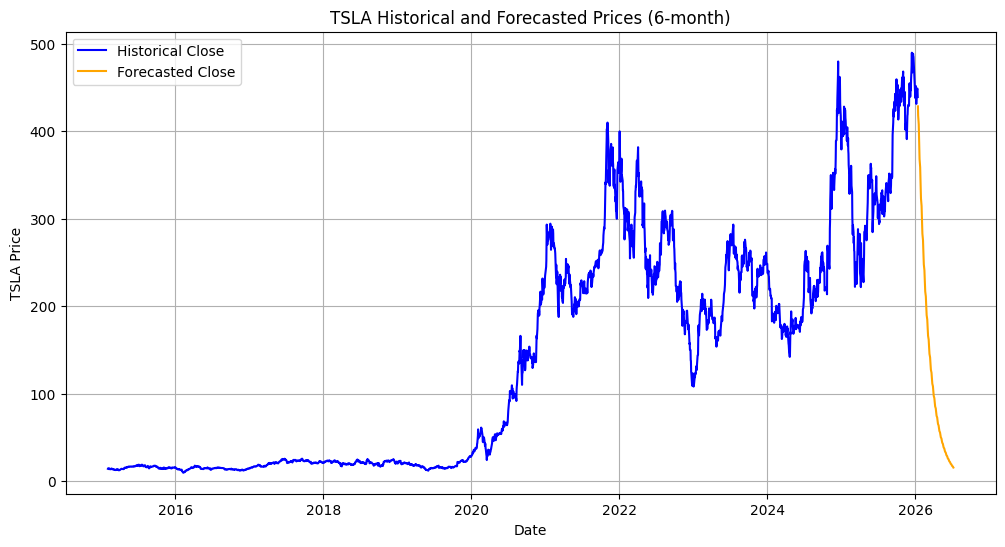

Cumulative forecasted return (6-month): -96.62%

Forecast Summary Statistics:


,Forecasted_Close,Forecasted_Return
count,126.000000,126.000000
mean,126.115908,-0.026536
std,112.956057,0.000367
min,15.508722,-0.026643
25%,35.661453,-0.026643
50%,81.997861,-0.026643
75%,188.532173,-0.026643
max,428.546309,-0.024556



Merged historical + forecasted data saved to TSLA_merged_hist_forecast.csv


In [8]:
# -----------------------------
# Task 3: Forecasting Models Analysis (Single Cell)
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Set paths
processed_path = "../data/processed"
tsla_hist_file = os.path.join(processed_path, "TSLA_cleaned.csv")
tsla_forecast_file = os.path.join(processed_path, "TSLA_forecasted_6mo.csv")

# -----------------------------
# 1. Load Data
# -----------------------------
tsla_hist = pd.read_csv(tsla_hist_file, parse_dates=["Date"])
tsla_forecast = pd.read_csv(tsla_forecast_file, parse_dates=["Date"])

# Preview
print("Historical TSLA Prices:")
display(tsla_hist.head())
print("Forecasted TSLA Prices and Returns:")
display(tsla_forecast.head())

# -----------------------------
# 2. Merge historical and forecasted prices
# -----------------------------
tsla_all = pd.concat([tsla_hist[['Date', 'Close']], 
                      tsla_forecast[['Date', 'Forecasted_Close']].rename(columns={'Forecasted_Close':'Close'})], 
                     ignore_index=True)

# Mark whether row is historical or forecast
tsla_all['Type'] = ['Historical']*len(tsla_hist) + ['Forecast']*len(tsla_forecast)

# -----------------------------
# 3. Plot Historical vs Forecasted Prices
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(tsla_hist['Date'], tsla_hist['Close'], label='Historical Close', color='blue')
plt.plot(tsla_forecast['Date'], tsla_forecast['Forecasted_Close'], label='Forecasted Close', color='orange')
plt.xlabel("Date")
plt.ylabel("TSLA Price")
plt.title("TSLA Historical and Forecasted Prices (6-month)")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 4. Compute cumulative forecasted return
# -----------------------------
tsla_forecast['Cumulative_Return'] = (1 + tsla_forecast['Forecasted_Return']).cumprod() - 1
print("Cumulative forecasted return (6-month): {:.2f}%".format(tsla_forecast['Cumulative_Return'].iloc[-1]*100))

# -----------------------------
# 5. Basic sanity checks
# -----------------------------
# Check for extreme drops or NaNs
if tsla_forecast['Forecasted_Close'].isna().any():
    print("Warning: NaN detected in forecasted prices")
if tsla_forecast['Forecasted_Return'].min() < -0.5:
    print("Warning: Very large negative return detected")
    
# Print summary stats
print("\nForecast Summary Statistics:")
display(tsla_forecast[['Forecasted_Close','Forecasted_Return']].describe())

# -----------------------------
# 6. Optional: Save merged TSLA dataset
# -----------------------------
tsla_all.to_csv(os.path.join(processed_path, "TSLA_merged_hist_forecast.csv"), index=False)
print("\nMerged historical + forecasted data saved to TSLA_merged_hist_forecast.csv")


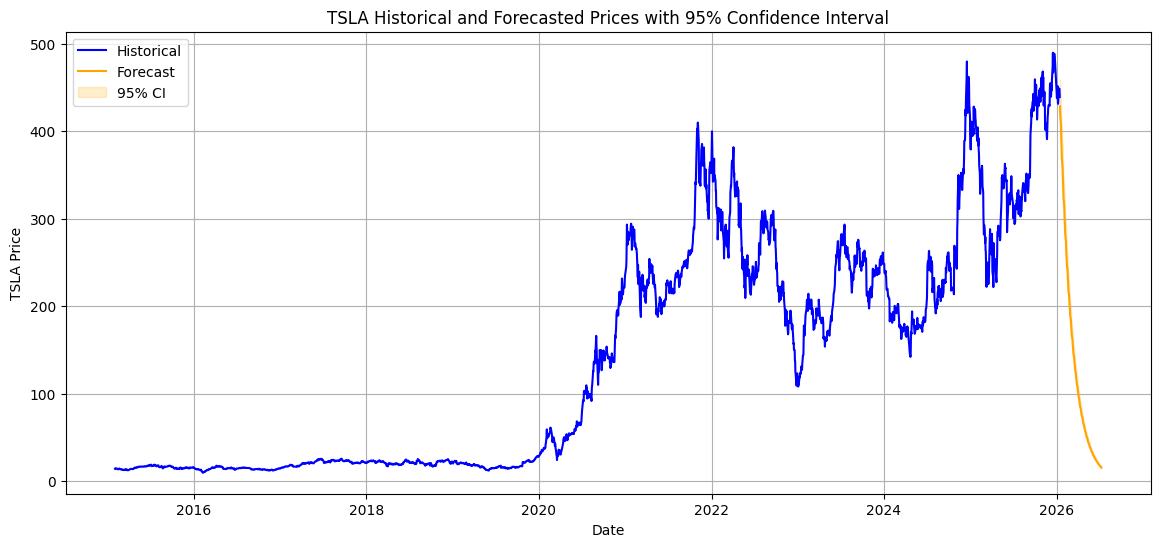

Forecast trend over 6 months is downward.
Forecast range: 15.51 - 428.55
Approximate 95% CI range: 14.40 - 459.13


In [11]:
# -----------------------------
# Task 3: TSLA Forecast Visualization with Confidence Interval
# -----------------------------

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load historical TSLA data
tsla_hist = pd.read_csv("../data/processed/TSLA_cleaned.csv", parse_dates=["Date"])
tsla_hist.sort_values("Date", inplace=True)

# Load LSTM forecasted data
tsla_forecast = pd.read_csv("../data/processed/TSLA_forecasted_6mo.csv", parse_dates=["Date"])
tsla_forecast.sort_values("Date", inplace=True)

# -----------------------------
# Approximate 95% Confidence Interval for Forecast
# -----------------------------

# Option: Use historical daily volatility
sigma_daily = tsla_hist['Return'].std()

# Forecasted prices
forecast_prices = tsla_forecast['Forecasted_Close']

# Compute CI bounds
ci_upper = forecast_prices * (1 + 1.96 * sigma_daily)
ci_lower = forecast_prices * (1 - 1.96 * sigma_daily)

# -----------------------------
# Plot Historical + Forecast + CI
# -----------------------------
plt.figure(figsize=(14,6))
plt.plot(tsla_hist['Date'], tsla_hist['Close'], label='Historical', color='blue')
plt.plot(tsla_forecast['Date'], forecast_prices, label='Forecast', color='orange')
plt.fill_between(tsla_forecast['Date'], ci_lower, ci_upper, color='orange', alpha=0.2, label='95% CI')

plt.xlabel("Date")
plt.ylabel("TSLA Price")
plt.title("TSLA Historical and Forecasted Prices with 95% Confidence Interval")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Optional: Trend Analysis Summary
# -----------------------------
trend_slope = np.polyfit(
    pd.to_numeric(tsla_forecast['Date']), 
    forecast_prices, 1
)[0]

if trend_slope > 0:
    trend = "upward"
elif trend_slope < 0:
    trend = "downward"
else:
    trend = "stable"

print(f"Forecast trend over 6 months is {trend}.")
print(f"Forecast range: {forecast_prices.min():.2f} - {forecast_prices.max():.2f}")
print(f"Approximate 95% CI range: {ci_lower.min():.2f} - {ci_upper.max():.2f}")
